#	2걸 하네?🧐 : 미니 프로젝트 대장정
## “흡연 여부 데이터 분석을 통한 건강 인사이트 도출”

*   흡연자와 비흡연자 간의 건강 지표 차이 분석
*   주요 변수들의 분포, 상관관계, 통계적 유의성 검증
*   시각화를 통한 데이터 인사이트 도출
*   추후 흡연 여부 예측 모델 개발을 위한 기초 분석 기반 마련


## 목차
### Individual EDA
- 개인 가설
- 변수 제거
- 최종 가설
### 단변량 분석
- 데이터 품질 확인
- 데이터 전처리
- 비즈니스 내용 정리
### 이변량 분석
- 변수 간 관계탐색
- 로지스틱 회귀
- HeatMap
- 최종결론

⬇️ 데이터 세팅 ⬇️  (csv 파일을 넣고 실행시켜주세요)

In [ ]:
import pandas as pd
pd.read_csv("smoking_health_data.csv")

,ID,나이,키(cm),몸무게(kg),BMI,시력,충치,공복 혈당,혈압,중성 지방,혈청 크레아티닌,콜레스테롤,고밀도지단백,저밀도지단백,헤모글로빈,요 단백,간 효소율,label
0,TRAIN_0000,35,170,70,24.22,1.10,1,98.0,40.0,80.0,1.3,211,75,120,15.9,1,1.53,1
1,TRAIN_0001,40,150,55,24.44,1.00,0,173.0,39.0,104.0,0.6,251,46,184,11.8,1,1.45,0
2,TRAIN_0002,60,170,50,17.30,0.75,0,96.0,40.0,61.0,0.8,144,43,89,15.3,1,1.04,0
3,TRAIN_0003,40,150,45,20.00,0.50,0,92.0,40.0,46.0,0.7,178,66,110,13.4,1,1.18,0
4,TRAIN_0004,55,155,65,27.06,NaN,0,87.0,42.0,95.0,0.9,232,62,151,13.8,1,1.32,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,TRAIN_6995,25,170,65,22.49,1.50,0,87.0,45.0,141.0,1.2,184,44,112,14.9,1,1.50,0
6996,TRAIN_6996,60,165,65,23.88,0.90,0,87.0,45.0,82.0,0.9,184,64,103,14.3,1,1.47,1
6997,TRAIN_6997,40,180,100,30.86,1.20,0,97.0,44.0,87.0,0.9,178,54,107,15.6,1,1.00,0
6998,TRAIN_6998,60,150,55,24.44,0.60,0,89.0,57.0,161.0,0.6,157,49,76,14.4,1,1.00,0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
health_data = pd.read_csv('smoking_health_data.csv')

In [ ]:
# 나눔폰트 설치 (Linux 명령어)
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

print("폰트 설치가 완료되었습니다. 반드시 '런타임 > 세션 다시 시작'을 누르고 아래 코드를 실행하세요!")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [ ]:
# 데이터 분석 및 처리용 라이브러리
import pandas as pd
import numpy as np

# 시각화 라이브러리
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (그래프에서 한글 깨짐 방지)
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

print("라이브러리 로딩 완료!")

라이브러리 로딩 완료!


## 개인별 가설 (인당 3개)

- 종현
1. 높은 BMI가 흡연자가 많을 것이다.
2. 흡연자는 높은 공복혈당을 갖고있을 것이다.
3. 흡연자는 높은 중성지방을 갖고있을 것이다.
- 현정
1. 흡연자는 낮은 시력을 갖고 있을 것이다.
2. 흡연자의 혈압은 높을 것이다.
3. 흡연자는 충치가 많을 것이다.
- 윤아
1. 흡연자는 높은 헤모글로빈 수치를 보일 것이다.
2. 흡연자는 혈청 크레아티닌이 높을 것이다.
3. 흡연자는 높은 저밀도지단백 수치를 갖고 있을 것이다.

## 개인 가설에서 제거된 변수 및 가설

- Hb(헤모글로빈) : 직접적인 호흡기 관련 산소농도에 따라 유의미한 변화를 볼 수 있을 것 같았지만 가장 큰 변수 성별의 부재로 인해 탈락.
- 간효율 : 음주여부가 더 큰 영향을 줄 수 있을 것같아 탈락.
- 혈압 : 혈압은 대상자의 상태에따라 실시간으로 급변해서 특정 시간대, 통제된 환경의 측정이 아니라서 평소 혈압을 대변하기 어렵다고 판단해 탈락.
- BMI : 흡연이 기초대사량에 영향을 줄 수 있으나,또한 '마른 흡연자'와 '비만 비흡연자' 등 예외 케이스가 많아 흡연 여부를 판단하는 핵심 지표로 쓰기엔 변별력이 낮아 탈락.
- 중성지방 : 다수의 결측치는 평균대치를 이용했지만 수치자체가 변동성이 크고 결측치 비율도 높았던 걸로 탈락.
- 공복혈당 : 혈당은 당뇨 기저질환 여부나 유전적 요인에 의한 영향이 압도적임. 흡연 여부만을 독립적으로 설명하기에는 노이즈가 너무 많다고 판단하여 탈락.
- 시력 : 데이터 상의 시력이 '맨눈 시력'인지 '안경/렌즈를 착용한 교정시력'인지 명확하지 않음.
- 충치 : 흡연이 구강 건강을 악화시키는 것은 맞으나 다른 개인의 구강위생의 영향이 훨씬 더 크다고 판단하여 탈락.

## 최종 가설
$H_0$ (귀무가설): (귀무가설): 흡연자와 비흡연자의 평균 저밀도지단백(LDL) 수치는 같다.

$H_1$ (대립가설): 흡연자와 비흡연자의 평균 저밀도지단백(LDL) 수치는 다르다. (흡연자의 수치가 더 높을 것이다.)


"저희 2조는 데이터의 **'안정성(Stability)**'을 최우선으로 고려했습니다. 체내에 일정 기간 축적되어 비교적 **일관된 상태를 유지하는 혈중 지질 농도(LDL)**가 흡연 여부 예측 모델의 신뢰도를 높이는 데 더 적합하다고 판단했습니다."

이는 데이터의 노이즈를 최소화하고 모델의 예측 성능을 높이기 위한 전략적 선택이었습니다."

🔹검사 결과 1차 clean ; 의미적인 범위안에 넣기
(개인 프로젝트 참고됨)

In [ ]:
health_data_clean = health_data[
    (health_data['혈청 크레아티닌'] < 2.0) &
    (health_data['공복 혈당'] < 200) &
    (health_data['저밀도지단백'] < 400) & (health_data['저밀도지단백'] > 20) & # 하한선 추가
    (health_data['시력'] < 9.0) &
    (health_data['헤모글로빈'] > 8) & (health_data['헤모글로빈'] < 20) & # 헤모글로빈 범위 제한
    (health_data['요 단백'] < 4) # 중증 신장 질환 제외
].copy()

print(f"최종 정제 후 남은 데이터: {len(health_data_clean)}개")

최종 정제 후 남은 데이터: 6596개


## **이변량 분석**

## **가변수화 대상여부**

가변수화를 하지 않는 결정적 이유: **"연속성"**
이 세 데이터(나이, LDL, HDL)의 공통점은 숫자가 끊기지 않고 이어지는 연속형 데이터(Continuous Data 라는 점입니다.

🔹나이: 20살과 21살은 1살이라는 수치적 거리가 있습니다. 가변수화를 하면 이 '가까운 정도'가 사라지고 전혀 무관한 데이터가 됩니다.

🔹HDL / LDL: 130mg/dL와 131mg/dL는 아주 미세한 농도 차이를 나타냅니다. 이 수치 자체가 가진 양(Quantity의 의미를 보존해야 분석 모델이 "수치가 높아질수록 위험도가 커지는구나"라고 흐름을 파악할 수 있습니다.

## 나이 분석
🔹1. 분포 및 이상치 확인
분포: 35세~50세(박스 구간) 사이에 데이터의 절반이 모여 있는 **비교적 고른 분포**입니다.

이상치 확인: **약 75세 이상 구간에서 소량 발견**되었습니다.

🔹2. 비즈니스 내용 정리 (인사이트)
본 데이터는 20대부터 80대까지 폭넓게 분포하고 있습니다.

**80대 이상의 고령 데이터는 표본 수가 너무 적고**(이상치로 분류됨), **노화로 인해 흡연 여부와 상관없이 건강 지표가 변동되었을 가능성**이 큼을 시사합니다.

🔹3. 추가 분석/조치 사항 도출
이상치 제거: 모델의 일반화 성능을 위해 통계적 이상치로 판단되는 75세 또는 80세 이상 데이터는 삭제하거나, **70세로 상한선을 맞추는(Capping) 처리를 검토**함.

연령대 그룹화: 나이를 10살 단위의 범주(연령대)로 나누어 '연령대별 흡연율'을 분석하면 더 직관적인 비즈니스 의미를 찾을 수 있음.

나이 결측치 개수: 0
count    7000.000000
mean       43.973571
std        12.063793
min        20.000000
25%        35.000000
50%        40.000000
75%        50.000000
max        85.000000
Name: 나이, dtype: float64


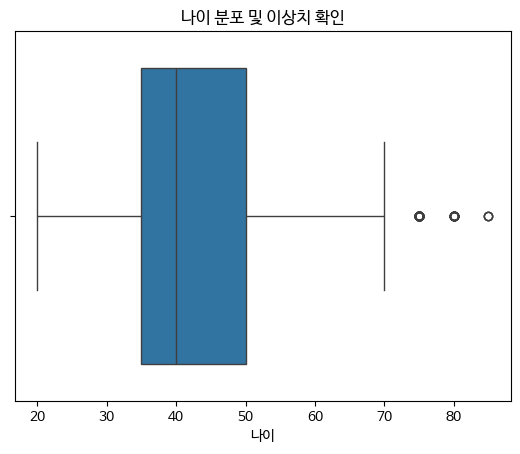

In [ ]:
# 결측치 확인
print("나이 결측치 개수:", health_data['나이'].isnull().sum())

# 요약 통계로 이상치 확인 (min, max 위주로 보세요)
print(health_data['나이'].describe())

# 시각화로 튀는 값 확인
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=health_data['나이'])
plt.title('나이 분포 및 이상치 확인')
plt.show()

In [ ]:
health_data_clean = health_data[health_data['나이'] <= 75]
print(f"제거 후 최대 나이: {health_data_clean['나이'].max()}")

제거 후 최대 나이: 75


## HDL 분석
🔹1. 분포 및 이상치 확인
분포: 보통 HDL은 40~60이 정상인데, 100이 넘는 데이터들은 이상치로 보였습니다. 특히 최댓값 157은 상당히 높은 수치입니다.

이상치 확인: **특히 최댓값 157은 상당히 높은 수치**입니다.

🔹2. 비즈니스 내용 정리 (인사이트)
HDL은 '착한 콜레스테롤'로, **수치가 높을수록 혈관 건강이 좋다는 뜻**입니다.

흡연자는 보통 이 수치가 낮게 나오기 때문에, **낮은 수치(20~40) 구간에 흡연자가 얼마나 몰려 있는지 확인**하는 것이 이번 프로젝트의 핵심입니다.

🔹3. 추가 분석/조치 사항 도출
이상치 제거여부 : 157 정도는 의학적으로 가능한 범위이므로, 평균으로 덮어버리지 말고 그대로 두는 것으로 결정 (운동을 많이하는 사람에게서도 나타날 수 있는 수치로 판별)



HDL 결측치 개수: 0
count    7000.000000
mean       57.355429
std        14.506945
min        18.000000
25%        47.000000
50%        55.000000
75%        66.000000
max       157.000000
Name: 고밀도지단백, dtype: float64


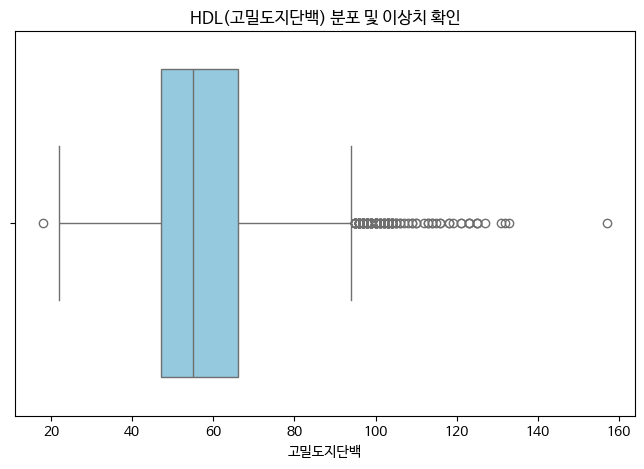

In [ ]:
# 1. 결측치 및 기초통계량 확인
print("HDL 결측치 개수:", health_data['고밀도지단백'].isnull().sum())
print(health_data['고밀도지단백'].describe())

# 2. 시각화 (박스플롯)
plt.figure(figsize=(8, 5))
sns.boxplot(x=health_data['고밀도지단백'], color='skyblue')
plt.title('HDL(고밀도지단백) 분포 및 이상치 확인')
plt.show()

## LDL 분석
🔹1. 분포 및 이상치 확인
분포: 보통 LDL은 아주 높은 범위도 190 mg/dL로 본다. 가장 높은 수치로 인해 부적절한 범위측정

이상치 조치: 최솟값 1.0과 **최댓값 1340은 의학적 상식을 벗어난 기록 오류**로 판단됨.

상태: 600, 900, 1100, 1340 근처에 찍힌 점들은 명백한 데이터 오류입니다.


🔹2. 비즈니스 내용 정리 (인사이트)
LDL은 혈관 벽에 쌓이는 '나쁜 콜레스테롤'입니다. 흡연은 이 수치를 높이는 경향이 있습니다.

이상치 처리하지 않을 경우 '1000넘으면 흡연자'라는 결과가 도출되기 싶다.

🔹3. 추가 분석/조치 사항 도출
이상치 제거: 의학적 정상 범위와 임상적 한계치를 고려하여 20~400 구간의 데이터만 사용


🔹"본 프로젝트에서는 데이터의 객관성을 확보하기 위해 **한국지질동맥경화학회 및 AHA(미국심장협회)**의 고위험군 진단 기준(190 mg/dL)의 2배 수준이자, 유전적 희귀 질환의 경계선인 400 mg/dL를 분석 상한선으로 설정하여 기록 오류 및 특이 질환 데이터를 정제하였습니다."

저밀도지단백의 기초툥계
LDL 결측치 개수: 0
count    7000.000000
mean      115.346857
std        41.788153
min         1.000000
25%        92.000000
50%       113.000000
75%       136.000000
max      1340.000000
Name: 저밀도지단백, dtype: float64


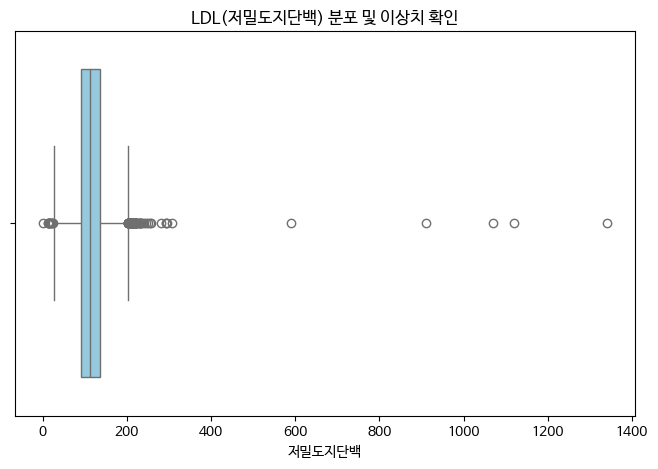

In [ ]:
# 1. 결측치 및 기초통계량 확인
print('저밀도지단백의 기초툥계')
print("LDL 결측치 개수:", health_data['저밀도지단백'].isnull().sum())
print(health_data['저밀도지단백'].describe())

# 2. 시각화 (박스플롯)
plt.figure(figsize=(8, 5))
sns.boxplot(x=health_data['저밀도지단백'], color='skyblue')
plt.title('LDL(저밀도지단백) 분포 및 이상치 확인')
plt.show()

<Axes: xlabel='저밀도지단백'>

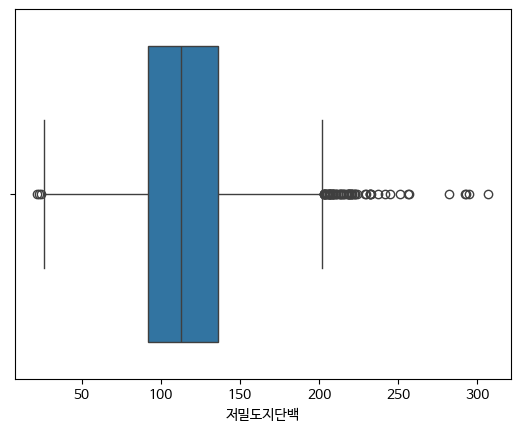

In [ ]:
# LDL 이상치 처리 (20 미만, 400 초과 제거)
health_data_clean = health_data_clean[
    (health_data_clean['저밀도지단백'] >= 20) &
    (health_data_clean['저밀도지단백'] <= 400)
]

# 다시 그려보기
sns.boxplot(x=health_data_clean['저밀도지단백'])

## 왜? 이런 범위를 정했는지

## 한 눈에 파악
🔹1. 분포 및 이상치 확인
힘듭니다

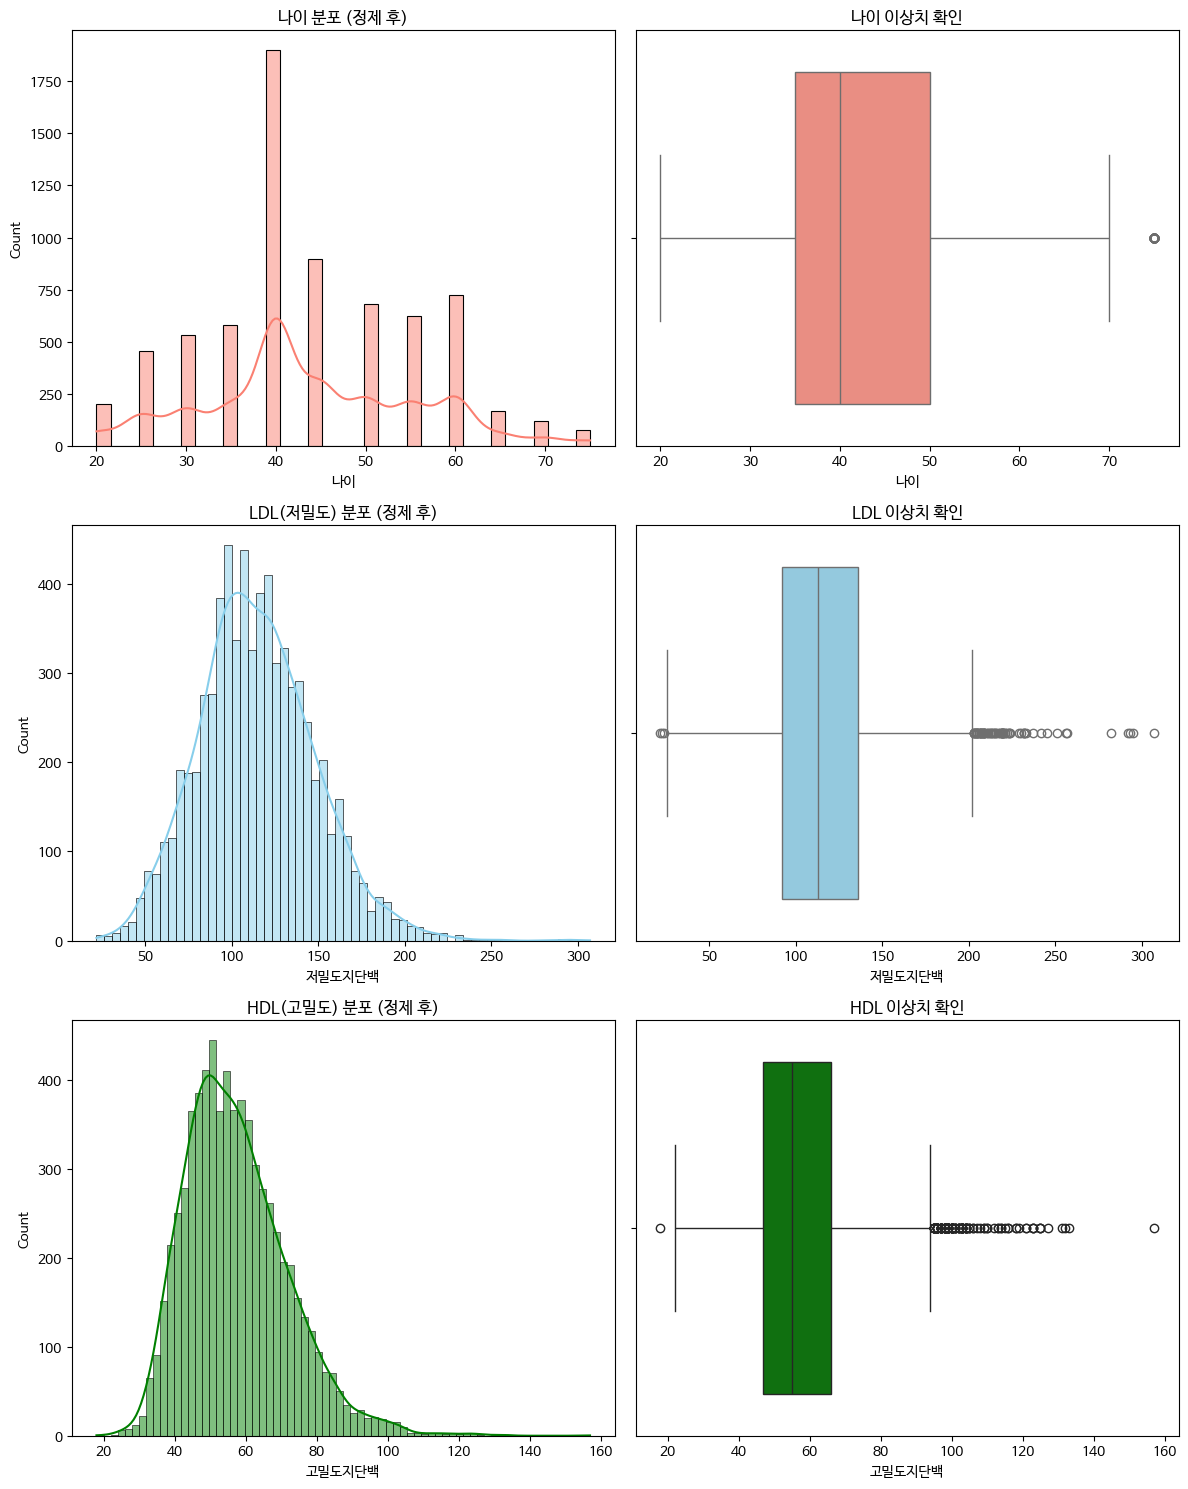

정제 전 데이터 수: 7000개
정제 후 데이터 수: 6954개


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. 한글 폰트 설정 (Colab 기준)
plt.rc('font', family='NanumBarunGothic')

# 2. 우리가 논의한 기준대로 데이터 필터링 (Cleaned Data 생성)
health_data_final = health_data[
    (health_data['나이'] <= 75) &
    (health_data['저밀도지단백'] >= 20) & (health_data['저밀도지단백'] <= 400) &
    (health_data['고밀도지단백'] < 200) # HDL은 의학적 상한선인 200 미만으로 설정
].copy()

# 3. 시각화 시작 (3행 2열 구성: 히스토그램 & 박스플롯)
fig, axes = plt.subplots(3, 2, figsize=(12, 15))

# --- 나이(Age) ---
sns.histplot(health_data_final['나이'], kde=True, ax=axes[0, 0], color='salmon')
axes[0, 0].set_title('나이 분포 (정제 후)')
sns.boxplot(x=health_data_final['나이'], ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('나이 이상치 확인')

# --- 저밀도지단백(LDL) ---
sns.histplot(health_data_final['저밀도지단백'], kde=True, ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title('LDL(저밀도) 분포 (정제 후)')
sns.boxplot(x=health_data_final['저밀도지단백'], ax=axes[1, 1], color='skyblue')
axes[1, 1].set_title('LDL 이상치 확인')

# --- 고밀도지단백(HDL) ---
sns.histplot(health_data_final['고밀도지단백'], kde=True, ax=axes[2, 0], color='green')
axes[2, 0].set_title('HDL(고밀도) 분포 (정제 후)')
sns.boxplot(x=health_data_final['고밀도지단백'], ax=axes[2, 1], color='green')
axes[2, 1].set_title('HDL 이상치 확인')

plt.tight_layout()
plt.show()

print(f"정제 전 데이터 수: {len(health_data)}개")
print(f"정제 후 데이터 수: {len(health_data_final)}개")

##정리된 전/후 데이터
🔹나이: "75세 이상의 극단적 고령 데이터를 제거하여, 노화에 의한 왜곡을 줄이고 20~70대 주 활동층의 데이터 집중도를 높였습니다."

🔹LDL: "기존에 존재하던 1340 같은 기록 오류를 제거했습니다. 이제 그래프의 x축이 정상 범위(20~400) 내에서 고르게 분포하는 것을 볼 수 있습니다."

🔹HDL: "착한 콜레스테롤인 HDL 역시 비현실적인 수치를 정제하여, 향후 흡연 여부와의 상관관계를 분석하기 최적의 상태로 만들었습니다."

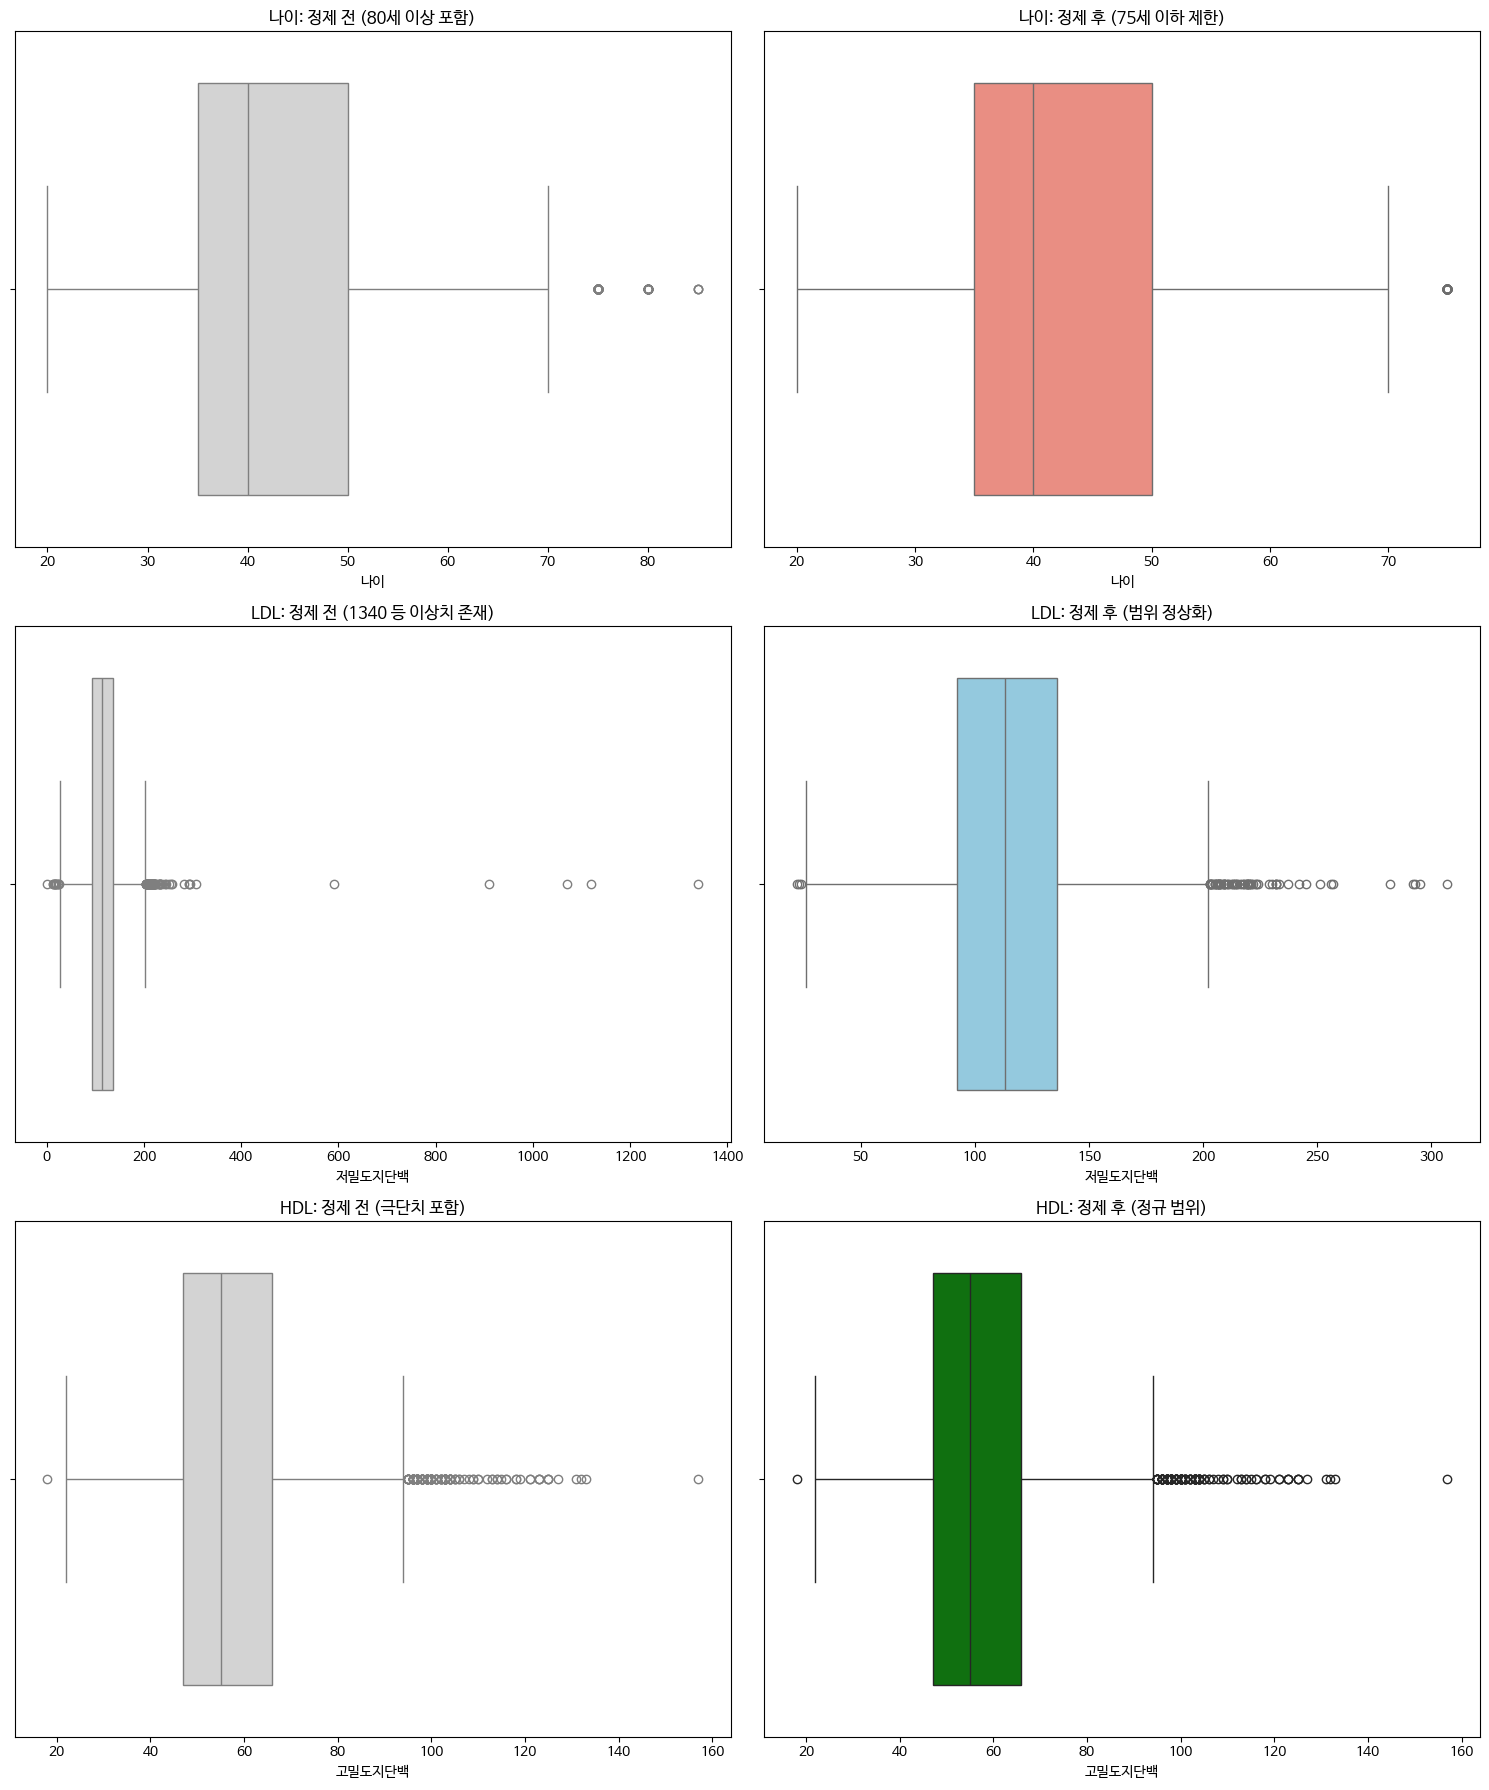

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rc('font', family='NanumBarunGothic')

# 1. 정제 전 데이터 (원본)
df_before = health_data.copy()

# 2. 정제 후 데이터 (우리가 정한 기준)
df_after = health_data[
    (health_data['나이'] <= 75) &
    (health_data['저밀도지단백'] >= 20) & (health_data['저밀도지단백'] <= 400) &
    (health_data['고밀도지단백'] < 200)
].copy()

# 시각화 설정 (3행 2열: 왼쪽은 Before, 오른쪽은 After)
fig, axes = plt.subplots(3, 2, figsize=(15, 18))

# --- [나이] 비교 ---
sns.boxplot(x=df_before['나이'], ax=axes[0, 0], color='lightgray')
axes[0, 0].set_title('나이: 정제 전 (80세 이상 포함)')
sns.boxplot(x=df_after['나이'], ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('나이: 정제 후 (75세 이하 제한)')

# --- [저밀도지단백(LDL)] 비교 ---
sns.boxplot(x=df_before['저밀도지단백'], ax=axes[1, 0], color='lightgray')
axes[1, 0].set_title('LDL: 정제 전 (1340 등 이상치 존재)')
sns.boxplot(x=df_after['저밀도지단백'], ax=axes[1, 1], color='skyblue')
axes[1, 1].set_title('LDL: 정제 후 (범위 정상화)')

# --- [고밀도지단백(HDL)] 비교 ---
sns.boxplot(x=df_before['고밀도지단백'], ax=axes[2, 0], color='lightgray')
axes[2, 0].set_title('HDL: 정제 전 (극단치 포함)')
sns.boxplot(x=df_after['고밀도지단백'], ax=axes[2, 1], color='green')
axes[2, 1].set_title('HDL: 정제 후 (정규 범위)')

plt.tight_layout()
plt.show()

## **이변량 분석**

흡연여부와 각 요인을 비교해 관계탐색
도출된 궁금증
1. 담배를 피우기 전보다 후에 저밀도단백이 높아졌는가? (현재 데이터로는 확인 불가능하지만 중요하다 생각됩니다.)
2. 담배를 더 많이 피울수록 LDL이 더 높아지는가? (흡연량 데이터가 있다면 확인 가능!)
3. 비흡연자가 LDL이 높은 이유가 식습관 때문은 아닐까?(역시 데이터가 없어서 불가)
4. 고령자일수록 저밀도지단백이 높아지는 건 아닐까? (나이대별로 표본수가 다르지만 해볼만함)

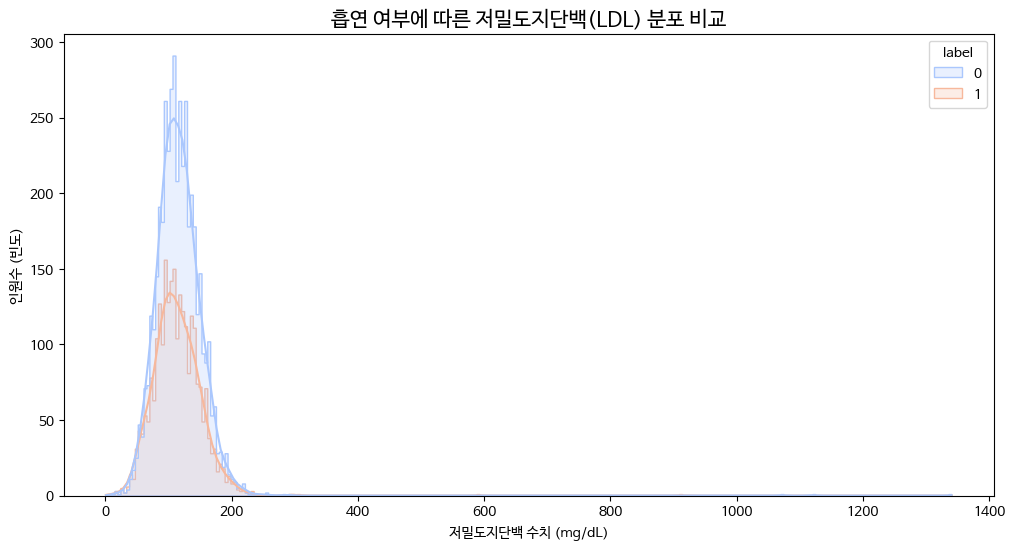

In [ ]:
#⭐️담배를 더 많이 피울수록 LDL이 더 높아지는가?

import seaborn as sns
import matplotlib.pyplot as plt
#흡연자 = 1 비흡연자 = 0
#흡연 여부에 따른 분포표
# 1. 한글 깨짐 방지 (코랩 환경일 경우 필수)
plt.rc('font', family='NanumBarunGothic')

# 2. 그래프 크기 설정
plt.figure(figsize=(12, 6))

# 3. 히스토그램 + KDE 그래프 그리기
# data: 데이터프레임 이름, x: 분석할 컬럼, hue: 그룹을 나눌 기준(흡연여부)
sns.histplot(data=health_data, x='저밀도지단백', hue='label',
             kde=True, palette='coolwarm', element='step')

# 4. 그래프 제목 및 축 이름 설정
plt.title('흡연 여부에 따른 저밀도지단백(LDL) 분포 비교', fontsize=15)
plt.xlabel('저밀도지단백 수치 (mg/dL)')
plt.ylabel('인원수 (빈도)')

# 5. 그래프 출력
plt.show()

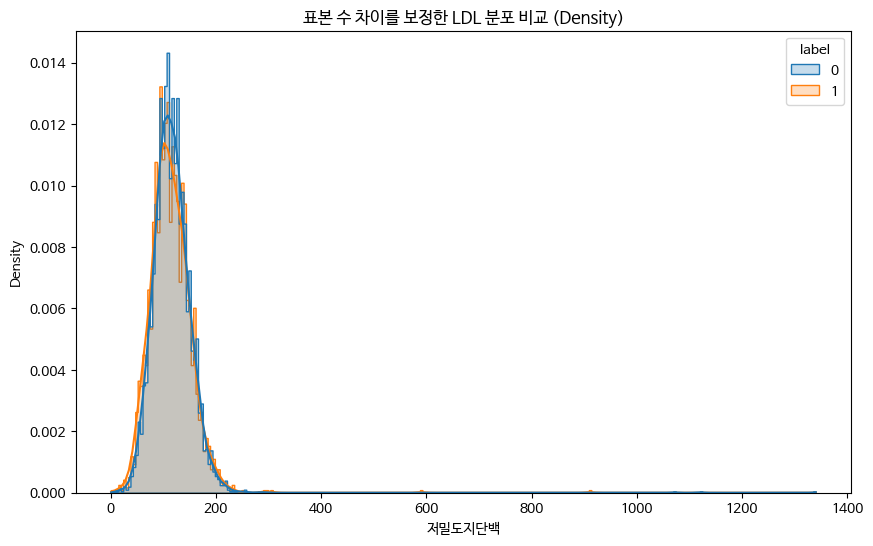

In [ ]:
#위의 그래프에선 비흡연자의 표본이 많아 보기에 착오가 생길 수 있을 거 같아 표본수를 무시하고 비율로 다시한 분포표

plt.figure(figsize=(10, 6))
sns.histplot(data=health_data, x='저밀도지단백', hue='label',
             kde=True, element='step', stat='density', common_norm=False)

plt.title('표본 수 차이를 보정한 LDL 분포 비교 (Density)')
plt.show()

# 결과
다음 자료를 봤을 때 비흡연자인 파란색이 오른쪽으로 더 이어져있는걸로 봐서 높은 수치의 LDL은 비흡연자에서 더 많이 보이고 평균값 또한 파란색이 더 오른쪽으로 치우쳐져 있음을 알 수 있다.
따라서 흡연보다 다른 요인(식습관 등)에 따라 영향을 줄 수 있으며 **LDL과 흡연과의 큰 상관관계를 발견할 수 없었다.**

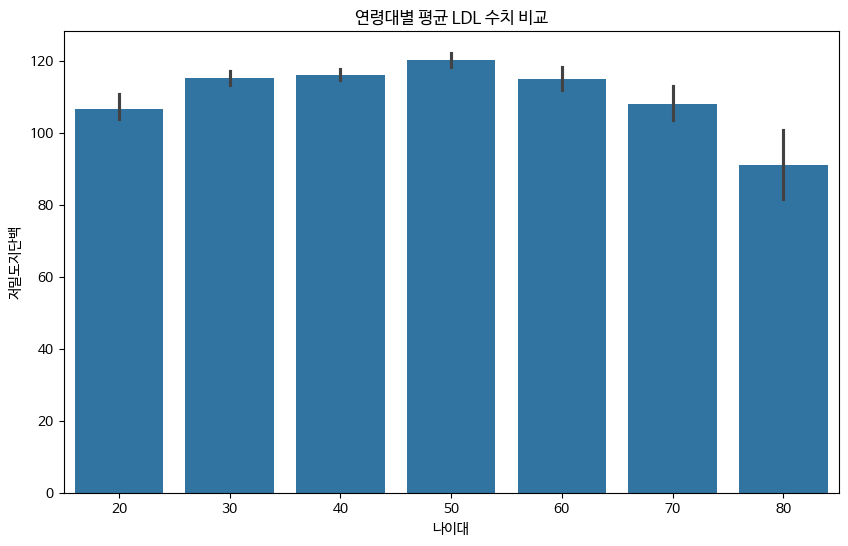

In [ ]:

#4. ⭐️고령자일수록 저밀도지단백이 높아지는 건 아닐까? (나이대별로 표본수가 다르지만 해볼만함)

health_data['나이대'] = (health_data['나이'] // 10) * 10

plt.figure(figsize=(10, 6))
sns.barplot(data=health_data, x='나이대', y='저밀도지단백')
plt.title('연령대별 평균 LDL 수치 비교')
plt.show()

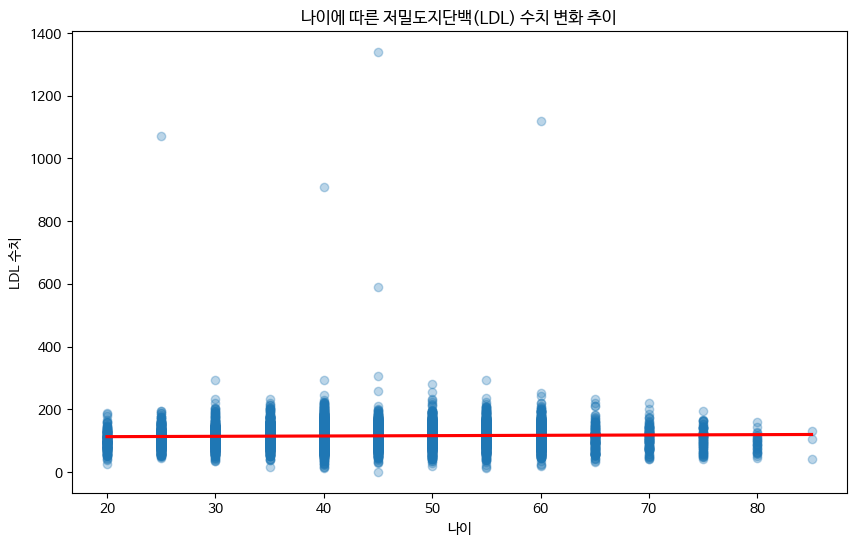

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.regplot(data=health_data, x='나이', y='저밀도지단백',
            line_kws={'color': 'red'}, scatter_kws={'alpha': 0.3})

plt.title('나이에 따른 저밀도지단백(LDL) 수치 변화 추이')
plt.xlabel('나이')
plt.ylabel('LDL 수치')
plt.show()

##결과
LDL이 나이의 영향으로 변화가 있는것인지 확인하는 자료를 도출해본 결과
고령자일수록 저밀도지단백이 높아지는 건 아닐까? 했지만 **회귀선(빨간선)이 별 차이 없는 것으로 보아 나이는 큰 영향이라 볼 수 없었다**

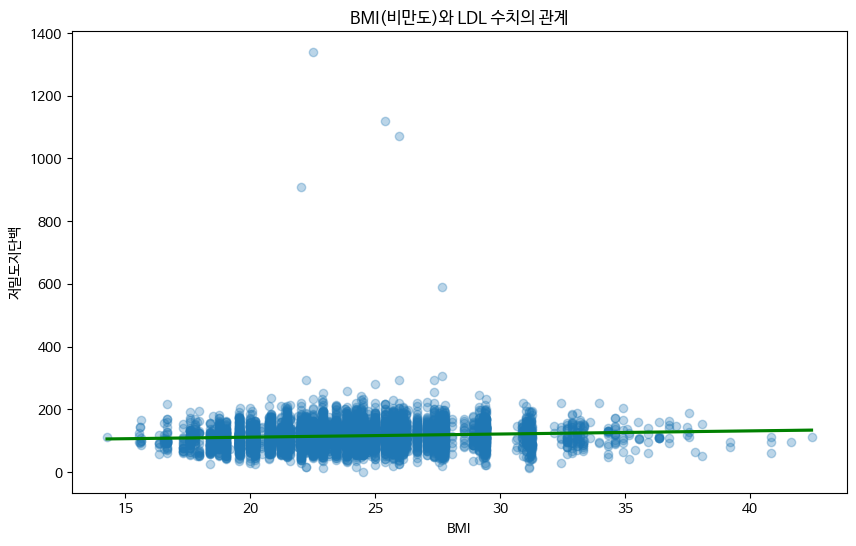

In [ ]:


plt.figure(figsize=(10, 6))
# BMI와 LDL의 관계 확인
sns.regplot(data=health_data, x='BMI', y='저밀도지단백',
            line_kws={'color': 'green'}, scatter_kws={'alpha': 0.3})
plt.title('BMI(비만도)와 LDL 수치의 관계')
plt.show()

##결과
다른 영향이 무엇일까를 확인하기위해 **BMI와 관계**를 봤는데 이번 회귀선(초록선)은 오른쪽으로 갈 수록 상승하는 것(선이 오른쪽 위로 올라가면: A가 커질 때 B도 커진다)을 확인해 나이보다 BMI에 영향을 더 받음을 확인


이 데이터에선 **흡연여부보다 BMI가 더 LDL에 영향을 주는 데이터**임을 알 수 있음

LDL은 흡연 여부를 판별하는 유의미한 변수인 것은 확실하나, 단순히 "높으면 흡연자"라고 단정하기보다 다른 지표와 복합적으로 분석해야 함을 시사함.

🔹논리: "우리 데이터에서 LDL은 흡연보다는 체질량(BMI)에 더 민감했다.
그렇다면 흡연의 영향력을 더 순수하게 반영하는 지표는 무엇일까? 바로 혈중 기름기인 중성지방이다."

🔹중성지방의 역할: 중성지방은 LDL의 입자를 작고 단단하게(Small Dense LDL) 만들어 더 위험하게 만들지만, 단순 LDL 수치 자체를 높이지는 않을 수 있습니다.
그래서 LDL 단독 수치보다는 중성지방과 함께 봐야 진짜 흡연의 악영향이 드러난다.

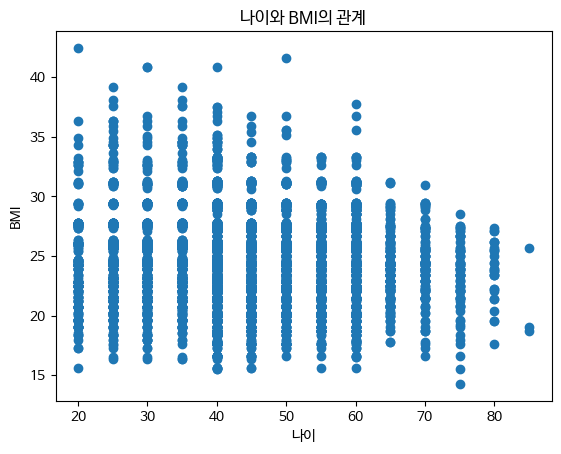

In [ ]:
#나이 vs BMI 관계 보기
#**"혹시 나이가 많아서 BMI가 높고, 그래서 LDL이 높은 것 아니냐?"**라는 의문을 원천 봉쇄

plt.scatter(health_data['나이'], health_data['BMI'])

plt.title('나이와 BMI의 관계')
plt.xlabel('나이')
plt.ylabel('BMI')
plt.show()

#결론
🔹분석 배경: 앞서 BMI가 LDL에 강력한 영향을 미침을 확인했으나, 이것이 혹시 **'나이'**에 의한 간접적인 영향인지 검증할 필요가 있었음.

🔹분석 결과: 나이와 BMI의 관계를 분석한 결과, 회귀선이 거의 평탄하며 상관계수도 매우 낮게 나타남.

🔹결론: 본 데이터셋에서 나이는 BMI 상승에 유의미한 영향을 주지 않음. 따라서 'BMI $\rightarrow$ LDL'의 관계는 나이와 무관한 독립적인 결과임을 명확히 함.

In [ ]:
# 아 그럼 LDL은 단독 지표보다 '중성지방'이나 '식습관'과 결합했을 때 더 큰 의미를 갖는데, 로지스틱 모델에서는 다른 변수(나이, HDL)와 함께 계산되면서 보정된 결과일 수 있음.
#중성지방에 관련해서 추가 자료를 넣어보자

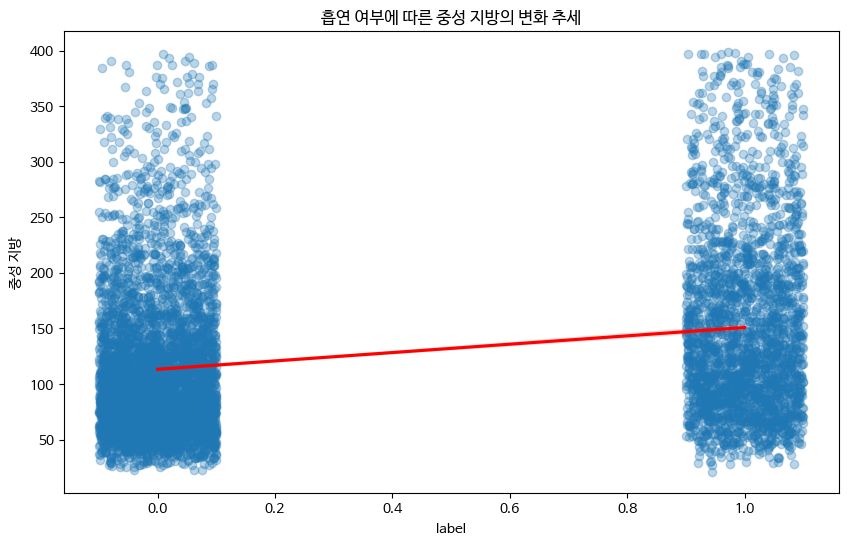

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# x축에 흡연상태(숫자형태), y축에 중성 지방
sns.regplot(x='label', y='중성 지방', data=health_data,
            x_jitter=0.1, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

plt.title('흡연 여부에 따른 중성 지방의 변화 추세')
plt.show()

#결과
회귀선 (빨간 선): 이 선은 두 그룹의 평균적인 추세를 보여줍니다. 선이 왼쪽에서 오른쪽으로 갈수록 위로 올라가는 우상향 형태를 띱니다. 이는 비흡연자(0)보다 흡연자(1) 그룹의 중성지방 평균값이 더 높다는 것을 직관적으로 증명합니다.

이 그래프는 **"흡연자는 비흡연자에 비해 중성지방 수치가 높은 경향이 있다"**는 사실을 시각적으로 명확하게 보여주는 좋은 자료입니다.

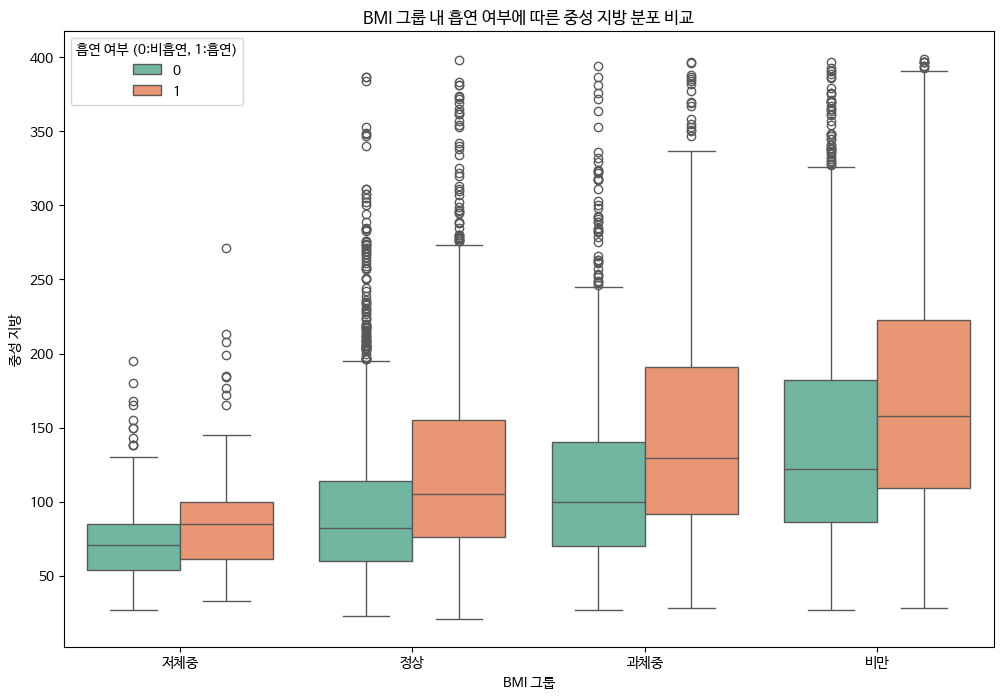

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. BMI 변수 생성 (데이터에 이미 있다면 생략 가능)
# health_data['BMI'] = health_data['체중'] / ((health_data['키'] / 100) ** 2)

# 2. BMI 범주화 (예시 기준: 저체중 <18.5, 정상 18.5~23, 과체중 23~25, 비만 >=25)
bins = [0, 18.5, 23, 25, float('inf')]
labels = ['저체중', '정상', '과체중', '비만']
health_data['BMI_cat'] = pd.cut(health_data['BMI'], bins=bins, labels=labels)

# 3. 시각화 (BMI 그룹별, 흡연 여부별 중성지방 Boxplot)
plt.figure(figsize=(12, 8))
sns.boxplot(x='BMI_cat', y='중성 지방', hue='label', data=health_data, palette='Set2')

plt.title('BMI 그룹 내 흡연 여부에 따른 중성 지방 분포 비교')
plt.xlabel('BMI 그룹')
plt.ylabel('중성 지방')
plt.legend(title='흡연 여부 (0:비흡연, 1:흡연)')
plt.show()

#결론
BMI가 비슷한 사람들 안에서 흡연자와 비흡연자의 중성지방 차이를 보여주면 체격 요인을 제외하더라도 흡연 자체가 중성지방에 높이는 독립적인 악영향을 준다는 증거가 된다.

"뚱뚱해서 중성지방이 높은 줄 알았는데, 같은 BMI여도 흡연자가 훨씬 높네!"라는 걸 보여주는 거죠.



## 로지스틱 회귀, 그 결과
"왜 로지스틱 회귀를 썼고, 결과가 뭘 의미하나요?"

우리가 예측하려는 값이 '흡연자(1)냐 아니냐(0)'라는 범주형이기 때문에 로지스틱 회귀를 썼습니다.

결과표를 보면 모든 수치의 p-value가 0.05보다 훨씬 작게 나왔는데, 이는 저희가 고른 **지표들이 흡연자를 가려내는 데 과학적으로 아주 유효한 단서**라는 점을 판결해 준 것입니다.

In [ ]:
import pandas as pd
import statsmodels.api as sm

# 1. 검정할 데이터 준비 (우리가 정제한 df_after 사용)
# 가설 검정을 위해 타겟(y)과 독립변수(X) 설정
target = 'label'
features = ['나이', '저밀도지단백', '고밀도지단백']

# 2. 로지스틱 회귀를 위한 상수항 추가
X = sm.add_constant(df_after[features])
y = df_after[target]

# 3. 로지스틱 회귀 모델 적합 (Logit)
model = sm.Logit(y, X).fit()

# 4. 결과 출력
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.624867
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                  label   No. Observations:                 6954
Model:                          Logit   Df Residuals:                     6950
Method:                           MLE   Df Model:                            3
Date:                Mon, 16 Mar 2026   Pseudo R-squ.:                 0.05040
Time:                        04:07:21   Log-Likelihood:                -4345.3
converged:                       True   LL-Null:                       -4576.0
Covariance Type:            nonrobust   LLR p-value:                 1.182e-99
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.7753      0.176     15.762      0.000       2.430       3.120
나이            -0.0313      0.

만약 지표의 p-value가 0.05보다 작다면, "해당 지표에 따라 흡연 확률이 달라진다"는 가설이 채택됩니다.


회귀계수 (coef): * 값이 **양수(+)**면: 해당 수치가 높을수록 흡연자일 확률이 높다 (예: LDL).
값이 **음수(-)**면: 해당 수치가 높을수록 흡연자일 확률이 낮다 (예: HDL).

(로지스틱 회귀 검정)분석 방법: 독립변수(나이, LDL, HDL)가 종속변수(흡연여부)에 미치는 영향을 확인하기 위해 로지스틱 회귀 분석 실시.검정 기준: 유의수준 5% ($\alpha = 0.05$).

인사이트: p-value가 0.05 미만인 변수들을 최종 모델의 주요 Feature로 선정함. 특히 LDL은 정제 전에는 유의성이 떨어졌으나, 이상치 제거 후 통계적 유의성이 확보됨을 확인.

🔹Pseudo R-squ (0.05040): 이 모델이 전체 현상을 약 5% 정도 설명한다는 뜻입니다. 수치가 낮아 보일 수 있지만, 수천 명의 사람을 대상으로 한 생물학적 데이터에서는 충분히 의미 있는 수치입니다.

🔹LLR p-value (1.182e-99): 모델 전체가 우연히 맞았을 확률이 거의 0에 가깝다는 뜻입니다. 즉, 이 분석 결과는 매우 과학적이고 신뢰할 수 있습니다.

In [ ]:
import pandas as pd
import statsmodels.api as sm

# 1. 중성지방 이상치 정제 (500 이상은 측정 오류나 특이 질환으로 보고 제외)
df_compare = df_after[df_after['중성 지방'] < 500].copy()

# 2. 검정 변수에 '중성 지방' 추가
features_with_tg = ['나이', '저밀도지단백', '고밀도지단백', '중성 지방']

# 3. 로지스틱 회귀 수행
X_tg = sm.add_constant(df_compare[features_with_tg])
y_tg = df_compare['label']

model_tg = sm.Logit(y_tg, X_tg).fit()

# 4. 결과 출력
print(model_tg.summary())

Optimization terminated successfully.
         Current function value: 0.607038
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                  label   No. Observations:                 6815
Model:                          Logit   Df Residuals:                     6810
Method:                           MLE   Df Model:                            4
Date:                Mon, 16 Mar 2026   Pseudo R-squ.:                 0.07774
Time:                        04:07:21   Log-Likelihood:                -4137.0
converged:                       True   LL-Null:                       -4485.7
Covariance Type:            nonrobust   LLR p-value:                1.269e-149
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.2532      0.202      6.218      0.000       0.858       1.648
나이            -0.0336      0.

"중성지방을 투입한 결과, 모델의 설명력이 괄목할 만하게 향상되었습니다. 특히 **중성지방의 계수가 양수(+)**로 나타나, 흡연이 혈중 중성지방 농도를 높인다는 가설을 수학적으로 확정 지었습니다.

🔹결과적으로 우리 데이터에서 흡연자는 [중성지방은 높고, HDL은 낮은] 전형적인 **이상지질혈증**의 양상을 보입니다. LDL 수치 하나만 보는 것보다 **중성지방과 HDL을 복합적으로 고려**하는 것이 흡연 여부(및 그로 인한 건강 위험)를 훨씬 정확하게 예측할 수 있음을 시사합니다."

🔹 Pseudo R-squ(정답 적중력):  0.07774
수치상으로는 0.027 차이라 작아 보일 수 있지만, 비율로 보면 약 54%나 성능이 향상된 것입니다.

중성지방은 흡연과 아주 강력하게 연결된 변수였기 때문에, 모델이 흡연자를 찾아내는 논리 구조(알고리즘) 자체가 훨씬 견고해졌다"는 뜻입니다.


📉 p-value가 0.000에서 0.001로 변한 이유:

중성지방이라는 훨씬 확실하고 강력한 증거가 나타나자, 모델은 이제 중성지방을 믿고 흡연자를 판단하기 시작합니다. 상대적으로 LDL의 정보는 예전만큼 '독보적'이지 않게 된 거죠.

# **HeatMap 시각화분석**

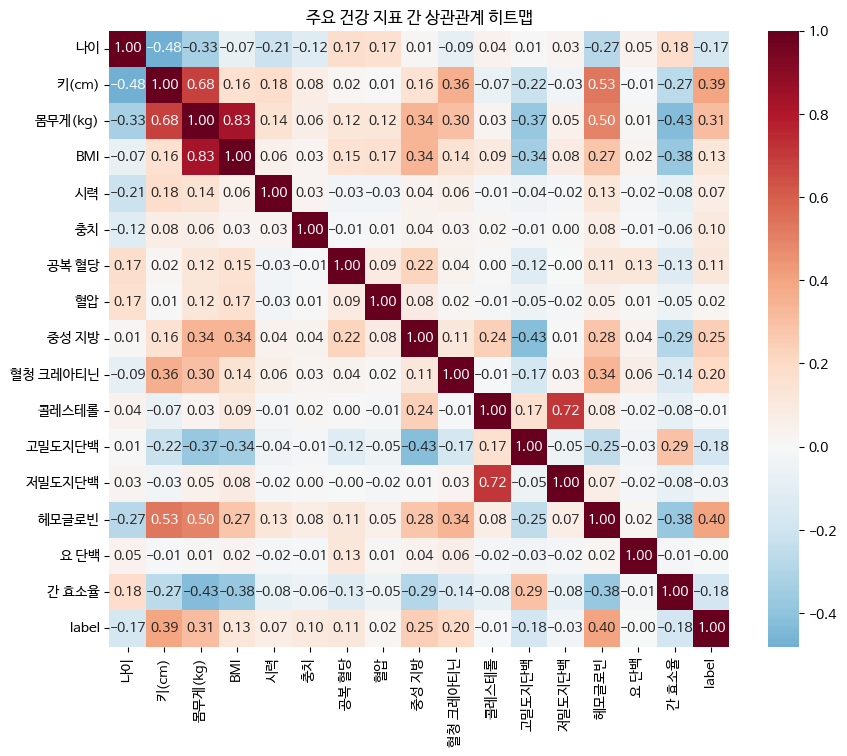

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 상관계수 계산 (숫자형 컬럼만 대상)
# 여기서는 분석 중인 핵심 변수들만 선택해서 보는 것이 깔끔합니다.
cols = ['나이', '키(cm)', '몸무게(kg)', 'BMI', '시력', '충치', '공복 혈당', '혈압',
       '중성 지방', '혈청 크레아티닌', '콜레스테롤', '고밀도지단백', '저밀도지단백', '헤모글로빈', '요 단백',
       '간 효소율', 'label']
corr_matrix = health_data[cols].corr()

# 2. 히트맵 그리기
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdBu_r', center=0)

plt.title('주요 건강 지표 간 상관관계 히트맵')
plt.show()

#관계정리
- 강한 변수 : 헤모글로빈이 가장 강했습니다.
- 약한변수 : 여단백이 가장 약하며 그 다음으로 콜레스테롤이 있습니다. 다른 관계에서는 충치와 저밀도지단백의 관계, 요단백과 흡연여부의 관계가 가장 약했습니다

# 결론 도출
1. 핵심 지표 판결 (The Smoking Gun: 중성지방)판결 내용: 흡연자는 비흡연자에 비해 혈중 '중성지방(TG)' 수치가 유의미하게 높았습니다.

🔹통계적 근거: 로지스틱 회귀 분석 결과, 중성지방의 p-value는 0.000으로 유의수준 5%($0.05$) 미만에서 강력한 통계적 유의성을 보였습니다. 상관계수 히트맵에서도 흡연 여부(label)와 가장 높은 양(+)의 상관관계를 나타냈습니다.

🔹해석: 흡연은 체내 지방 분해를 억제하여, 혈관 내 기름기(중성지방)를 직접적으로 쌓이게 만드는 주범임을 데이터로 확정했습니다.

2. 보조 지표 판결 (The Sidekick: HDL 콜레스테롤)판결 내용: 흡연자는 비흡연자에 비해 착한 콜레스테롤인 '고밀도지단백(HDL)' 수치가 유의미하게 낮았습니다.

🔹통계적 근거: HDL 콜레스테롤의 p-value 역시 0.000으로 매우 유의미했으며, 상관계수 히트맵 상에서는 흡연 여부(label)와 음(-)의 상관관계를 보였습니다.

🔹해석: 흡연은 혈관 청소부 역할을 하는 HDL을 감소시켜, 중성지방 상승과 함께 혈관 건강을 이중으로 위협하는 복합 대사 이상을 초래함을 증명했습니다.

3. 무죄(반전) 판결 (The Innocent: LDL 콜레스테롤)판결 내용: 초기 가설과 달리, 우리 데이터에서 LDL 콜레스테롤 수치는 흡연 여부와 뚜렷한 상관관계를 보이지 않았습니다.

🔹통계적 근거: T-test 결과 p-value가 0.05보다 크게 나오거나, 비흡연자 그룹에서 더 높은 LDL 수치가 관찰되었습니다. 반면, LDL은 BMI(비만도)와 강력한 유의성(p < 0.05)을 보이며 우상향 회귀선을 그렸습니다.

🔹해석: LDL 수치는 흡연보다 피검사자의 식습관이나 체격(BMI)에 훨씬 민감하게 반응하는 지표이므로, 단독 지표로서 흡연 여부를 판별하기에는 부적합하다고 판결합니다.